**CUSTOMER CHURN PREDICTION**

###### **-->** The objective is to predict customers who are likely to churn and identify key drivers behind churn to design retention strategies.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

**Reading Dataset**

In [ ]:
data = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
data.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


**Data Preprocessing**

In [ ]:
data.shape

(7043, 21)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
data[data.duplicated()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [ ]:
data.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [ ]:
categorical = [columns for columns in data if data[columns].dtypes == object]
categorical

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn']

In [ ]:
numerical = [columns for columns in data if data[columns].dtypes != object]
numerical

['SeniorCitizen', 'tenure', 'MonthlyCharges']

###### **-->** Data preprocessing reveals that the dataset consists of 7,043 observations and 21 features, of which 18 are categorical and 3 are numerical. Furthermore, no missing values or duplicate entries were found.
###### **-->** Although no null values are detected, the TotalCharges column contains empty strings or their datatype is object and will be converted to numeric during preprocessing.


**Exploratory Data Analysis**

**What percentage of customers churn? - Churn distribution**

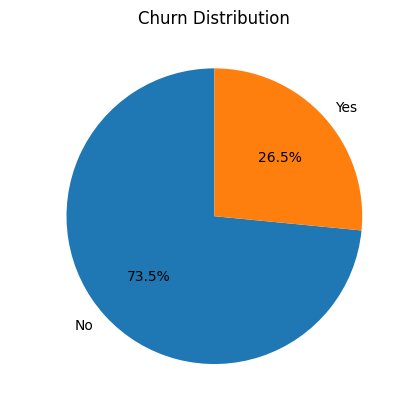

In [ ]:
data['Churn'].value_counts().plot.pie(autopct = '%1.1f%%', startangle = 90)
plt.ylabel(' ')
plt.title("Churn Distribution")
plt.show()

###### **-->** The pie chart shows that the majority of customers (73.5%) remain with the company, whereas 26.5% of customers have churned.

**Does churn depend on contract type? - Churn vs Contract**

In [ ]:
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

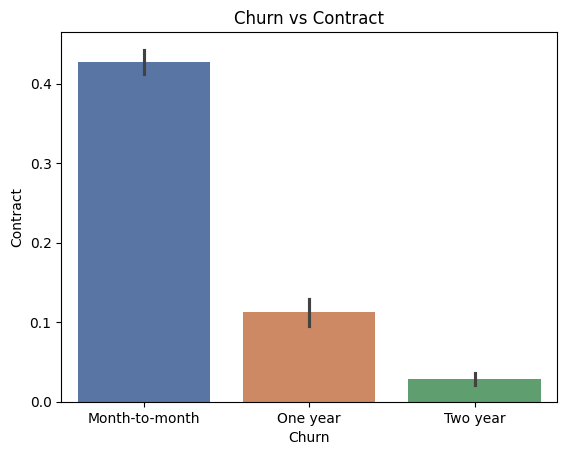

In [ ]:
sns.barplot(x = 'Contract', y = 'Churn', data = data, palette = 'deep')
plt.xlabel('Churn')
plt.ylabel('Contract')
plt.title('Churn vs Contract')
plt.show()

###### **-->** Month-to-month customers have the highest churn rate (around 43%), One-year contract customers churn much less (around 11%), Two-year contract customers have the lowest churn rate (around 3%).
###### **-->** Customers on short-term (month-to-month) contracts are far more likely to leave, Long-term contracts strongly reduce churn, Contract length is a key factor influencing customer retention.
###### **-->** Encouraging customers to move from month-to-month → long-term contracts can significantly reduce churn, Month-to-month customers should be the primary target for retention strategies.
###### **-->** The chart indicates that churn is highest among month-to-month customers and decreases significantly as contract duration increases, with two-year contracts having the lowest churn rate.

**Does churn increase with monthly charges? - Churn vs MonthlyCharges**

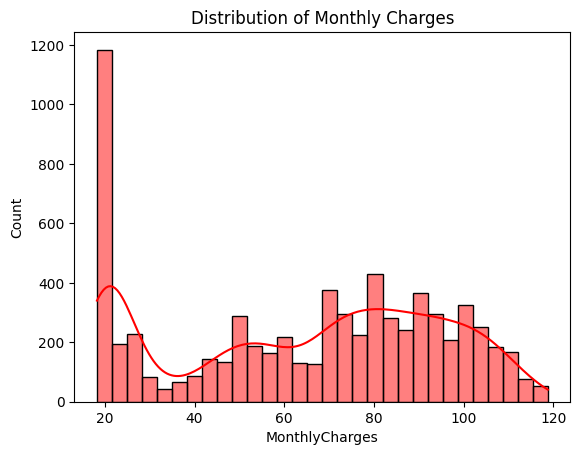

In [ ]:
sns.histplot(data['MonthlyCharges'], bins=30, kde=True, color = 'red')
plt.title('Distribution of Monthly Charges')
plt.show()

###### **-->** The distribution is not uniform and appears right-skewed
###### **-->** The histogram shows that monthly charges are widely distributed, with most customers concentrated in lower (around $20 - $30) and higher price ranges(around $70 - $100).

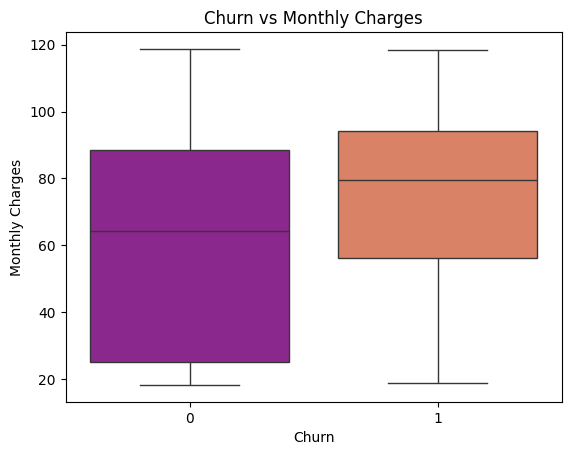

In [ ]:
sns.boxplot(x = 'Churn', y = 'MonthlyCharges', data = data, palette = 'plasma')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')
plt.title('Churn vs Monthly Charges')
plt.show()

###### **-->** Customers paying higher monthly charges are more likely to churn, Lower-priced plans tend to have better customer retention, Monthly charges are a strong indicator of churn. The churned group shows less spread at lower values, indicating fewer low-cost customers churn
###### **-->** The box plot indicates that customers with higher monthly charges are more likely to churn compared to customers with lower monthly charges.

**Do new customers churn more? - Churn vs tenure**

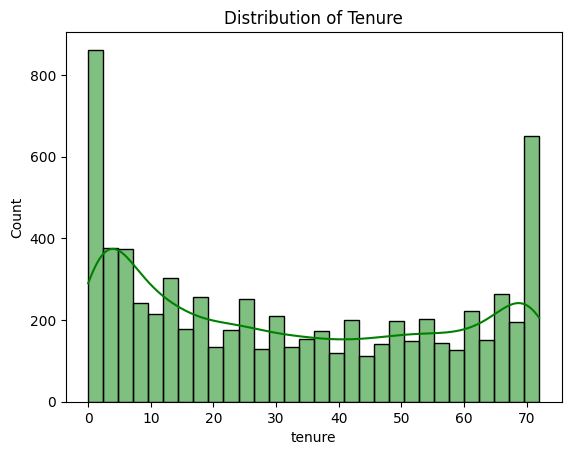

In [ ]:
sns.histplot(data['tenure'], bins=30, kde=True, color = 'green')
plt.title('Distribution of Tenure')
plt.show()

###### **-->** Tenure ranges from 0 to about 72 months, A large number of customers have very low tenure (new customers), Another concentration exists at high tenure values (long-term customers), The distribution is U-shaped, not normal
###### **-->** Many customers either leave early or stay for a very long time, Fewer customers are in the mid-tenure range, Customer base consists of new customers and loyal long-term customers
###### **-->** The tenure distribution shows a high concentration of customers with very short and very long service durations.

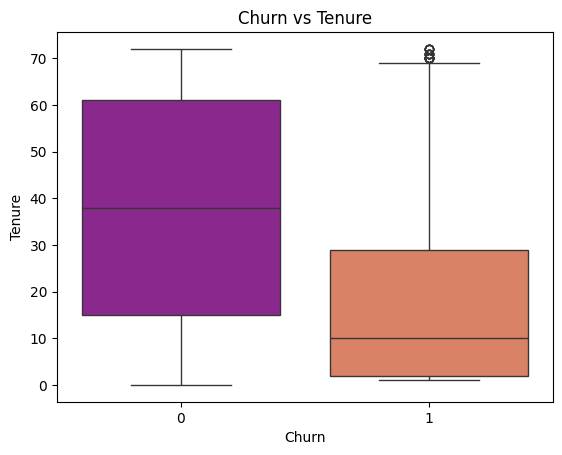

In [ ]:
sns.boxplot(x = 'Churn', y = 'tenure', data = data, palette = 'plasma')
plt.xlabel('Churn')
plt.ylabel('Tenure')
plt.title('Churn vs Tenure')
plt.show()

###### **-->** Churned customers (1) have much lower tenure, Non-churn customers (0) have significantly higher tenure
###### **-->** Median tenure: Churn = 1 → around 10 months & Churn = 0 → around 35 - 40 months
###### **-->** Customers are most likely to churn in the early months, Long-term customers are far less likely to leave, Tenure is one of the strongest predictors of churn
###### **-->** The box plot indicates that customers with shorter tenure are more likely to churn, while long-tenure customers tend to remain with the service.

**Does Payment Method Influence Customer Churn? - Churn vs PaymentMethod**

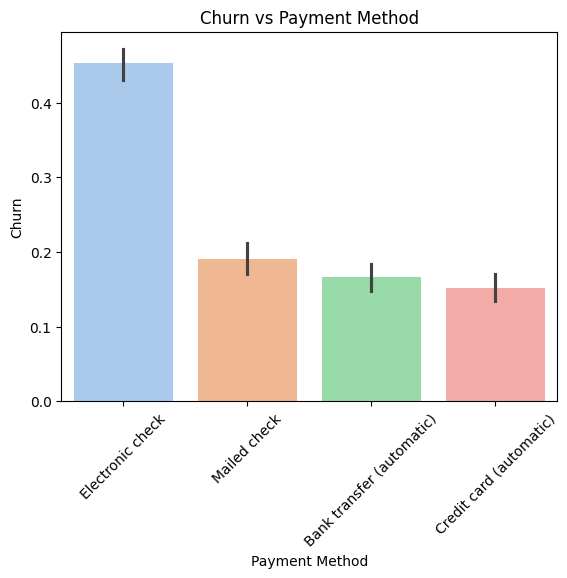

In [ ]:
sns.barplot(x = 'PaymentMethod', y = 'Churn', data = data, palette = 'pastel')
plt.xlabel('Payment Method')
plt.ylabel('Churn')
plt.title('Churn vs Payment Method')
plt.xticks(rotation = 45)
plt.show()

###### **-->** Customers using manual payment methods are more likely to churn, Automatic payment methods reduce churn, Electronic check users are the highest-risk group.
###### **-->** Encourage customers to switch to auto-pay options, Offer incentives for electronic check users to move to automatic payments.
###### **-->** The chart indicates that customers using electronic checks have the highest churn rate, while those using automatic payment methods exhibit significantly lower churn.

**Does Internet Service Type Affect Customer Churn? - Churn vs InternetService**

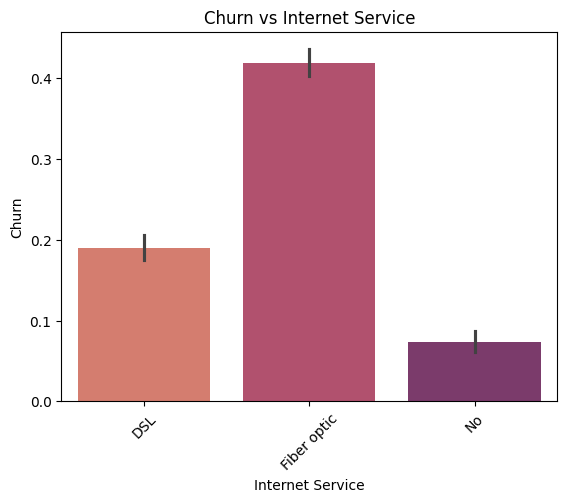

In [ ]:
sns.barplot(x = 'InternetService', y = 'Churn', data = data, palette = 'flare')
plt.xlabel('Internet Service')
plt.ylabel('Churn')
plt.title('Churn vs Internet Service')
plt.xticks(rotation = 45)
plt.show()

###### **-->** Despite being a premium service, fiber optic users churn more Possible reasons: Higher cost, Service quality expectations not met, Strong competition in fiber services.
###### **-->** Fiber optic customers should be priority targets for retention Review pricing, service reliability, and customer support for fiber plans.
###### **-->** The analysis shows that fiber optic internet customers experience significantly higher churn compared to DSL and non-internet service customers.


**Summary of Key Churn Drivers -->**
**1.   Contract Type**
**2.   Monthly Charges**
**3.   Tenure**
**4.   Payment Method**
**5.   Internet Service**














